In [1]:
import numpy as np
import seaborn as sns
import random
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
# metod generise rcbd tabelu tako sto je popuni sa nasumicnim brojevima iz [lower, upper] --> ovo je okej jer mi radimo sa vestackim podacima
# generalno gledano to nisu nasumicne vrednosti vec izmerene vrednosti u eksperimentu
def generate_rcbd_table(n_rows = 2, n_cols = 2, lower_bound = 1, upper_bound = 30, seed=None):
    if seed is not None:
        np.random.seed(seed)

    data = np.random.randint(lower_bound, upper_bound + 1, size=(n_rows, n_cols))
    df = pd.DataFrame(data,
                      index=[f"T{i+1}" for i in range(n_rows)],
                      columns=[f"B{j+1}" for j in range(n_cols)])
    return df

In [3]:
def calculate_sse(predicted, true, mask):
    predicted = predicted.astype(float)
    true = true.astype(float)
    error = (predicted - true) ** 2
    #print("Error matrix:\n", error)
    masked_error = error * mask
    #print("Masked error matrix:\n", masked_error)
    sse = np.sum(masked_error)
    return sse

<h4>Test primeri i vizualizacija razlike<h4>

In [4]:
# originalna RCBD tabela (npr. 3 tretmana x 3 bloka)
true_table = generate_rcbd_table(3, 3, 1, 20, 42)
display(true_table)
# maska:
mask = pd.DataFrame(0, index=true_table.index, columns=true_table.columns)
# izaberemo proizvoljna polja za promenu
mask.iloc[0, 1] = 1
mask.iloc[2, 2] = 1

# predlozene vrednosti koje bi GA dao kao rešenja
predicted_table = true_table.copy().astype(float)
predicted_table.iloc[0, 1] = 19.5
predicted_table.iloc[2, 2] = 12.5
sse = calculate_sse(predicted_table.values, true_table.values, mask.values)
print(f"SSE: {sse:.4f}")

,B1,B2,B3
T1,7,20,15
T2,11,8,7
T3,19,11,11


SSE: 2.5000


In [5]:
error_table = (predicted_table - true_table)
masked_error_table = error_table * mask

print("Razlika (samo na pozicijama sa greškom):")
display(masked_error_table)

Razlika (samo na pozicijama sa greškom):


,B1,B2,B3
T1,0.0,-0.5,0.0
T2,0.0,0.0,0.0
T3,0.0,0.0,1.5


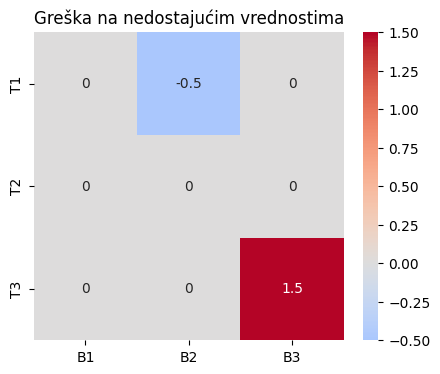

In [6]:
plt.figure(figsize=(5,4))
sns.heatmap(masked_error_table, annot=True, cmap="coolwarm", center=0)
plt.title("Greška na nedostajućim vrednostima")
plt.show()

In [7]:
#nasumicno uklanjanje jedne vrednosti iz rcbd tabele
def hide_random_value(table: pd.DataFrame, seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    table_hidden = table.copy() #kopija tabele sa jednom vrednošću zamenjenom sa np.nan

    rows, cols = table.shape
    i = random.randint(0, rows - 1)
    j = random.randint(0, cols - 1)
    #(i,j) je pozicija gde je vrednost uklonjena

    true_value = table_hidden.iat[i, j] #originalna vrednost na (i,j) poziciji
    table_hidden.iat[i, j] = np.nan

    return table_hidden, (i, j), true_value

In [8]:
#proba funkcije za uklanjanje jedne vrednosti
df = generate_rcbd_table(5, 5, 10, 30, 42)
print("Originalna tabela:")
display(df)

df_hidden, pos, original_val = hide_random_value(df, 42)

print("\nTabela sa skrivenom vrednošću:")
display(df_hidden)

print(f"\nUklonjena vrednost: {original_val} na poziciji {pos}")

Originalna tabela:


,B1,B2,B3,B4,B5
T1,16,29,24,20,17
T2,30,16,28,20,20
T3,30,13,17,12,30
T4,11,21,15,11,30
T5,10,21,21,26,19



Tabela sa skrivenom vrednošću:


,B1,B2,B3,B4,B5
T1,NaN,29,24,20,17
T2,30.0,16,28,20,20
T3,30.0,13,17,12,30
T4,11.0,21,15,11,30
T5,10.0,21,21,26,19



Uklonjena vrednost: 16 na poziciji (0, 0)


In [34]:
class Individual:
    def __init__(self, rcbd : pd.DataFrame, rcbd_true : pd.DataFrame):
        self.code = calculate_code(rcbd)
        self.rcbd = rcbd # table with missing value
        self.rcbd_true = rcbd_true
        self.fitness = self.calc_fitness()

    def calc_fitness(self):
        rcbd_c = self.rcbd.copy()
        decode_value, row, col = self.decode()
        rcbd_c.iloc[row, col] = decode_value
        mask = pd.DataFrame(0, index=self.rcbd.index, columns=self.rcbd.columns)        
        mask.iloc[row, col] = 1
        return -calculate_sse(rcbd_c.values, self.rcbd_true.values, mask.values)
    
    def binary_code(self):
      return ''.join(['1' if bit else '0' for bit in self.code])
        
    def decode(self):
      # (min (row where nan is) + int(self.code)) / 10
      t_row_ids, t_col_ids = np.where(self.rcbd.isna())
      t_row_id = t_row_ids[0]
      t_col_id = t_col_ids[0]

      t_values = self.rcbd.iloc[t_row_id].dropna().values
      min_value = min(t_values)

      decoded_value = (min_value + int(self.binary_code(), 2)) 
      return decoded_value, t_row_id, t_col_id

    def __str__(self):
        binary = self.binary_code()
        decoded_value, row, col = self.decode()
        return f"Chromosome binary code is {binary} and decoded value is {decoded_value} (at row {row}, column {col})\n"


In [35]:
# this function returns code for given individual (chromosome). Each individual should represent the missing value in the RCBD table.
def calculate_code(table : pd.DataFrame):
  # first we need to determine range for missing value.
  t_row_ids, _ = np.where(table.isna()) # treatment where the missing value occurs
  t_row_id = t_row_ids[0]

  # remove from the t_row_id the nan value
  t_values = table.iloc[t_row_id].dropna().values
  # scale all values as int
  #t_rounded_values = [round(v, 1) for v in t_values]
  #t_scaled_values = [int(round(v * 10)) for v in t_rounded_values]

  min_value = min(t_values)
  max_value = max(t_values)
  n = max_value - min_value + 1  # number of values in [min, max]
  size = math.ceil(math.log2(n)) # size of the chromosome
  chromosome = [random.random() < 0.2 for _ in range(size)]

  return chromosome

In [36]:
chromosome = Individual(df_hidden, df)

In [37]:
print(type(chromosome))

<class '__main__.Individual'>


In [38]:
print("Random generated chromosome: ", chromosome.binary_code())

Random generated chromosome:  0001


In [39]:
print("Random generated chromosome in its decimal format: ", chromosome.decode())

Random generated chromosome in its decimal format:  (18.0, 0, 0)


In [40]:
print("Fitness of this random generated chromosome is: ", chromosome.fitness)

Fitness of this random generated chromosome is:  -4.0


In [41]:
def initial_population(rcbd : pd.DataFrame, rcbd_true : pd.DataFrame, size = 10):
    population = []
    while(True):
        chromosome = Individual(rcbd, rcbd_true)
        decode_value, row, _ = chromosome.decode()

        # condition: decoded chromosome in range [min_value, max_value]
        t_values = rcbd_true.iloc[row].values
        min_value = min(t_values)
        max_value = max(t_values)

        if decode_value <= max_value and decode_value >= min_value:
            population.append(chromosome)

        if len(population) == size:
            break
            
    return population

In [42]:
population = initial_population(df_hidden, df)

In [44]:
for individual in population:
    print(individual)

Chromosome binary code is 0010 and decoded value is 19.0 (at row 0, column 0)

Chromosome binary code is 0110 and decoded value is 23.0 (at row 0, column 0)

Chromosome binary code is 1100 and decoded value is 29.0 (at row 0, column 0)

Chromosome binary code is 1001 and decoded value is 26.0 (at row 0, column 0)

Chromosome binary code is 0011 and decoded value is 20.0 (at row 0, column 0)

Chromosome binary code is 0000 and decoded value is 17.0 (at row 0, column 0)

Chromosome binary code is 0011 and decoded value is 20.0 (at row 0, column 0)

Chromosome binary code is 0000 and decoded value is 17.0 (at row 0, column 0)

Chromosome binary code is 0000 and decoded value is 17.0 (at row 0, column 0)

Chromosome binary code is 0101 and decoded value is 22.0 (at row 0, column 0)

